In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Remote DB starts at this size
remote_starting_size = 378146

# Growth speeds (seconds per +1 record)
remote_growth_rate_seconds = 15 * 60
local_growth_rate_seconds = 4

In [4]:
remote_size = lambda t_secs: remote_starting_size + (t_secs // remote_growth_rate_seconds)
local_size = lambda t_secs: t_secs // local_growth_rate_seconds

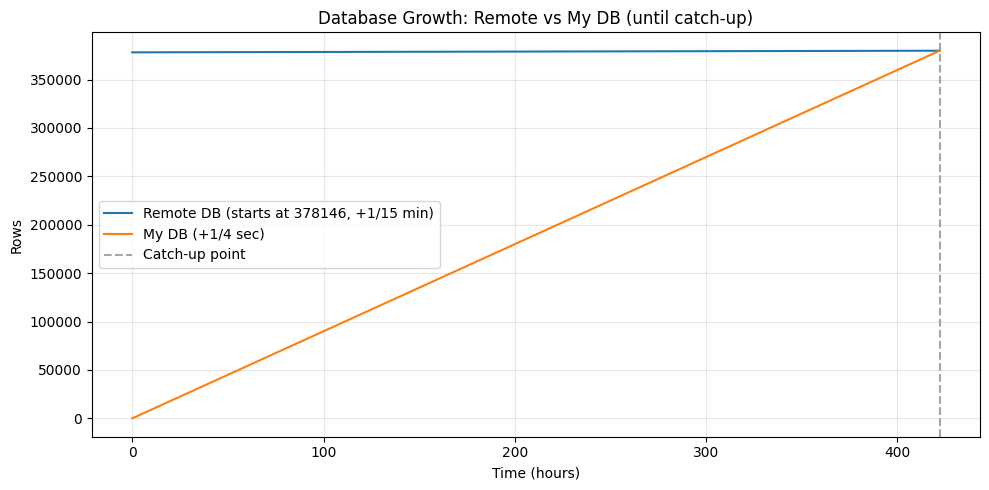

Catch-up time: 422.04 hours (17.58 days)


In [5]:
# Smallest t such that local_size(t) >= remote_size(t)
catch_up_seconds = int(np.ceil(
    remote_starting_size / (1 / local_growth_rate_seconds - 1 / remote_growth_rate_seconds)
))

# Make sure it satisfies the integer-step model exactly
while local_size(catch_up_seconds) < remote_size(catch_up_seconds):
    catch_up_seconds += 1

time = np.arange(0, catch_up_seconds + 1, 60)  # sample every minute
remote_db = remote_size(time)
local_db = local_size(time)

plt.figure(figsize=(10, 5))
plt.plot(time / 3600, remote_db, label="Remote DB (starts at 378146, +1/15 min)")
plt.plot(time / 3600, local_db, label="My DB (+1/4 sec)")
plt.axvline(catch_up_seconds / 3600, color="gray", linestyle="--", alpha=0.7, label="Catch-up point")
plt.xlabel("Time (hours)")
plt.ylabel("Rows")
plt.legend()
plt.title("Database Growth: Remote vs My DB (until catch-up)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Catch-up time: {catch_up_seconds/3600:.2f} hours ({catch_up_seconds/86400:.2f} days)")

In [6]:
time = np.arange(0, 1_000_000_000, growth_rate)
to_download = lambda x: 378146 + (x // (15 * 60)) - (x // 10)
plt.plot(time / 3600, to_download(time), label="Files to Download")
plt.show()

NameError: name 'growth_rate' is not defined

# Usando apenas Sitemap do G1, sem GDELT

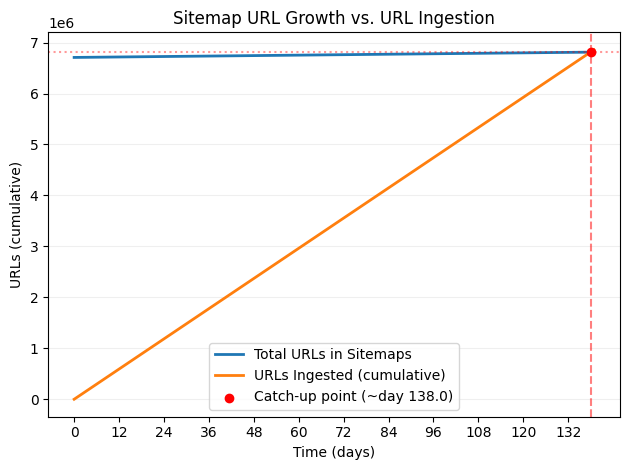

In [19]:
starting_sitemaps = 8944
avg_urls_per_sitemap = 750

total_sitemaps = lambda days: starting_sitemaps + days
total_urls = lambda days: total_sitemaps(days) * avg_urls_per_sitemap

urls_ingested_per_second = 1 / 1.75
urls_ingested_per_day = urls_ingested_per_second * 86400
urls_ingested = lambda days: urls_ingested_per_day * days

net_daily_catch_up = urls_ingested_per_day - avg_urls_per_sitemap
if net_daily_catch_up <= 0:
    raise ValueError("Ingestion rate is not enough to ever catch up.")

catch_up_days = (starting_sitemaps * avg_urls_per_sitemap) / net_daily_catch_up
time_days = np.arange(0, np.ceil(catch_up_days) + 1, 0.1)

plt.plot(time_days, total_urls(time_days), label="Total URLs in Sitemaps", linewidth=2)
plt.plot(time_days, urls_ingested(time_days), label="URLs Ingested (cumulative)", linewidth=2)

catch_up_urls = total_urls(catch_up_days)
plt.scatter([catch_up_days], [catch_up_urls], color="red", zorder=5, label=f"Catch-up point (~day {catch_up_days:.1f})")
plt.axvline(catch_up_days, color="red", linestyle="--", alpha=0.5)
plt.axhline(catch_up_urls, color="red", linestyle=":", alpha=0.4)

x_step = max(5, int(np.ceil(catch_up_days / 12)))
plt.xticks(np.arange(0, np.ceil(catch_up_days) + 1, x_step))
plt.xlabel("Time (days)")
plt.ylabel("URLs (cumulative)")
plt.title("Sitemap URL Growth vs. URL Ingestion")
plt.grid(axis="y", alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()